In [1]:
import sys, os
from pathlib import Path

print("Python executável:", sys.executable)
print("Pasta de trabalho:", os.getcwd())
print()

# Define a raiz do projeto de forma robusta, independente do cwd.
PROJECT_ROOT = Path(r"C:\Users\m\Documents\Tese\Article4")
DATA_DIR     = PROJECT_ROOT / "data"
RESULTS_DIR  = PROJECT_ROOT / "results"
REFS_DIR     = PROJECT_ROOT / "refs"

print("PROJECT_ROOT:", PROJECT_ROOT, "→ existe?", PROJECT_ROOT.exists())
print("DATA_DIR:    ", DATA_DIR,     "→ existe?", DATA_DIR.exists())
print()
print("Ficheiros em DATA_DIR:", [f.name for f in DATA_DIR.iterdir()])

Python executável: C:\Users\m\anaconda3\envs\tese-h2\python.exe
Pasta de trabalho: C:\Users\m\Documents\Tese\Article4\notebooks

PROJECT_ROOT: C:\Users\m\Documents\Tese\Article4 → existe? True
DATA_DIR:     C:\Users\m\Documents\Tese\Article4\data → existe? True

Ficheiros em DATA_DIR: ['oil_majors_h2_data_collection.xlsx']


In [2]:
import numpy as np
import pandas as pd
import pypsa

print(f"NumPy:  {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"PyPSA:  {pypsa.__version__}")

try:
    import highspy
    print("HiGHS:  instalado ✓")
except ImportError:
    print("HiGHS:  EM FALTA — corra numa célula:  !pip install highspy")

NumPy:  1.26.4
Pandas: 2.2.3
PyPSA:  0.35.1
HiGHS:  instalado ✓


In [3]:
# Configuração global do projeto
INVESTMENT_PERIODS = [2025, 2030, 2035, 2040, 2045, 2050]
FIRMS = ["Shell", "TotalEnergies", "BP", "Eni", "Repsol"]
CLIMATE_SCENARIOS = ["STEPS", "APS", "NZE"]
SEED = 42

def annuity_capex(overnight_eur_per_mw: float, wacc: float, lifetime_y: int) -> float:
    """
    Annualised CAPEX (€/MW/y) — usar como `capital_cost` no PyPSA.
    Aplica capital recovery factor (CRF) padrão financeiro.
    """
    if wacc == 0:
        return overnight_eur_per_mw / lifetime_y
    crf = wacc / (1 - (1 + wacc) ** -lifetime_y)
    return overnight_eur_per_mw * crf

# Sanity check: PEM 1500 €/kW (=1.5e6 €/MW), WACC 7%, 20 anos
test = annuity_capex(overnight_eur_per_mw=1_500_000, wacc=0.07, lifetime_y=20)
print(f"Teste: PEM 1500 €/kW → {test:,.0f} €/MW/y → {test/1000:.1f} €/kW/y")
print("(Valor esperado: ~141 €/kW/y — bate certo se aparecer ~141)")

Teste: PEM 1500 €/kW → 141,589 €/MW/y → 141.6 €/kW/y
(Valor esperado: ~141 €/kW/y — bate certo se aparecer ~141)


In [4]:
# Smoke test: 1 refinaria, 168h (uma semana), 1 ano de investimento.
# Objetivo: provar que PyPSA + HiGHS resolvem um problema trivial sem erros.

rng = np.random.default_rng(SEED)
N_HOURS = 168
hours_of_day = np.arange(N_HOURS) % 24

# Perfis sintéticos (substituídos depois pelos dados reais)
solar_cf = np.clip(
    np.sin((hours_of_day - 6) / 12 * np.pi) * 0.7 + rng.normal(0, 0.05, N_HOURS),
    0, 1,
)
solar_cf[(hours_of_day < 6) | (hours_of_day > 19)] = 0
wind_cf = np.clip(rng.beta(2, 4, N_HOURS) * 1.1, 0, 1)

# Procura constante de H2 ≈ 5 t/h numa refinaria média (LHV H2 = 33.33 MWh/t)
H2_DEMAND_T_PER_H = 5.0
h2_demand_mwh = H2_DEMAND_T_PER_H * 33.33

# Construção da rede
n = pypsa.Network()
n.set_snapshots(pd.RangeIndex(N_HOURS))

n.add("Carrier", "AC")
n.add("Carrier", "H2")

n.add("Bus", "power", carrier="AC")
n.add("Bus", "h2",    carrier="H2")

n.add("Load", "refinery_h2", bus="h2", p_set=h2_demand_mwh)

# Renováveis extendable — anuidade dividida por 52 para escalar 1 semana
n.add("Generator", "solar", bus="power",
      p_nom_extendable=True, p_max_pu=solar_cf,
      capital_cost=annuity_capex(800_000, 0.07, 25) / 52)
n.add("Generator", "wind",  bus="power",
      p_nom_extendable=True, p_max_pu=wind_cf,
      capital_cost=annuity_capex(1_300_000, 0.07, 25) / 52)

# Grid: capacidade fixa elevada, custo marginal = preço de mercado
n.add("Generator", "grid", bus="power", p_nom=1e6, marginal_cost=80.0)

# Eletrolisador PEM
n.add("Link", "pem", bus0="power", bus1="h2",
      p_nom_extendable=True, efficiency=0.65, p_min_pu=0.10,
      capital_cost=annuity_capex(1_500_000, 0.07, 20) / 52)

print(f"Rede construída: {len(n.buses)} buses, {len(n.generators)} generators, {len(n.links)} links")

# Resolver
import time
t0 = time.time()
status = n.optimize(solver_name="highs")
print(f"\nSolver: {status}   |   tempo: {time.time()-t0:.1f}s\n")

# Resultados
print(f"Capacidades ótimas:")
print(f"  Solar : {n.generators.at['solar','p_nom_opt']:>7.1f} MW")
print(f"  Wind  : {n.generators.at['wind', 'p_nom_opt']:>7.1f} MW")
print(f"  PEM   : {n.links.at['pem',      'p_nom_opt']:>7.1f} MW")

grid_share = n.generators_t.p['grid'].sum() / n.generators_t.p.sum().sum()
print(f"\nFração da eletricidade vinda da rede: {grid_share:.1%}")

# LCOH muito grosseiro: custo total / kg H2 produzido
total_cost = n.objective
h2_kg = n.loads_t.p['refinery_h2'].sum() / 33.33 * 1000
print(f"LCOH (estimativa grosseira semanal): {total_cost / h2_kg:.2f} €/kg")

Rede construída: 2 buses, 3 generators, 1 links


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.12s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 675 primals, 1683 duals
Objective: 2.86e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.



Solver: ('ok', 'optimal')   |   tempo: 1.2s

Capacidades ótimas:
  Solar :   138.0 MW
  Wind  :   552.0 MW
  PEM   :   256.4 MW

Fração da eletricidade vinda da rede: 23.1%
LCOH (estimativa grosseira semanal): 3.40 €/kg


In [5]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [6]:
print("p_max_pu dim_names:", n.generators_t.p_max_pu.columns.names if hasattr(n.generators_t.p_max_pu.columns, 'names') else 'no MI')
print("Snapshots type :", type(n.snapshots))

p_max_pu dim_names: ['Generator']
Snapshots type : <class 'pandas.core.indexes.range.RangeIndex'>


In [7]:
# Horizonte temporal — usando datetime, padrão oficial PyPSA
N_HOURS_PER_PERIOD = 24
YEARS_PER_PERIOD   = 5
DISCOUNT_RATE      = 0.05

# Curvas de aprendizagem (PLACEHOLDER — ligar depois ao Excel)
CAPEX_TRAJ = pd.DataFrame({
    "solar_capex": [ 800,  700,  600,  550,  500,  480],
    "wind_capex":  [1300, 1200, 1100, 1050, 1000,  980],
    "pem_capex":   [1500, 1300, 1100,  950,  850,  800],
    "pem_eff":     [0.65, 0.67, 0.69, 0.70, 0.71, 0.72],
    "wacc":        [0.07] * 6,
}, index=INVESTMENT_PERIODS)
CAPEX_TRAJ.index.name = "build_year"

# === SNAPSHOTS: padrão oficial PyPSA com datetime + MultiIndex.from_arrays ===
datetime_index = pd.DatetimeIndex([])
for year in INVESTMENT_PERIODS:
    period = pd.date_range(
        start=f"{year}-01-01 00:00",
        freq="h",
        periods=N_HOURS_PER_PERIOD,
    )
    datetime_index = datetime_index.append(period)

snapshots = pd.MultiIndex.from_arrays([datetime_index.year, datetime_index])

print("Curvas de aprendizagem:")
print(CAPEX_TRAJ)
print(f"\nTotal snapshots: {len(snapshots)}")
print(f"Primeiros 3 snapshots: {snapshots[:3].tolist()}")
print(f"Últimos 3 snapshots:   {snapshots[-3:].tolist()}")

Curvas de aprendizagem:
            solar_capex  wind_capex  pem_capex  pem_eff  wacc
build_year                                                   
2025                800        1300       1500     0.65  0.07
2030                700        1200       1300     0.67  0.07
2035                600        1100       1100     0.69  0.07
2040                550        1050        950     0.70  0.07
2045                500        1000        850     0.71  0.07
2050                480         980        800     0.72  0.07

Total snapshots: 144
Primeiros 3 snapshots: [(2025, Timestamp('2025-01-01 00:00:00')), (2025, Timestamp('2025-01-01 01:00:00')), (2025, Timestamp('2025-01-01 02:00:00'))]
Últimos 3 snapshots:   [(2050, Timestamp('2050-01-01 21:00:00')), (2050, Timestamp('2050-01-01 22:00:00')), (2050, Timestamp('2050-01-01 23:00:00'))]


In [8]:
import time

# === Construir a rede ===
n = pypsa.Network()
n.set_snapshots(snapshots)
n.set_investment_periods(INVESTMENT_PERIODS)

# Pesos de período (anos representados + fator de desconto)
T0 = INVESTMENT_PERIODS[0]
n.investment_period_weightings["years"]     = YEARS_PER_PERIOD
n.investment_period_weightings["objective"] = [
    (1 + DISCOUNT_RATE) ** -(y - T0) for y in INVESTMENT_PERIODS
]

# Pesos de snapshot — atribuir por COLUNAS individualmente (mais robusto)
sw_value = YEARS_PER_PERIOD * 8760 / N_HOURS_PER_PERIOD
n.snapshot_weightings["objective"]  = sw_value
n.snapshot_weightings["generators"] = sw_value
n.snapshot_weightings["stores"]     = sw_value

# === Perfis usando n.snapshots DIRETAMENTE (sem manipular nomes) ===
rng = np.random.default_rng(SEED)
hd  = np.arange(N_HOURS_PER_PERIOD) % 24
solar_24h = np.clip(np.sin((hd - 6) / 12 * np.pi) * 0.7 + rng.normal(0, 0.05, N_HOURS_PER_PERIOD), 0, 1)
solar_24h[(hd < 6) | (hd > 19)] = 0
wind_24h  = np.clip(rng.beta(2, 4, N_HOURS_PER_PERIOD) * 1.1, 0, 1)

solar_full = pd.Series(np.tile(solar_24h, len(INVESTMENT_PERIODS)), index=n.snapshots)
wind_full  = pd.Series(np.tile(wind_24h,  len(INVESTMENT_PERIODS)), index=n.snapshots)

h2_demand_per_period = {2025: 5, 2030: 5, 2035: 6, 2040: 7, 2045: 8, 2050: 10}
h2_demand_full = pd.Series(
    [h2_demand_per_period[y] * 33.33 for y, _ in n.snapshots],
    index=n.snapshots,
)

# Carriers e buses
for c in ["AC", "H2", "solar", "onwind", "pem", "grid"]:
    n.add("Carrier", c)
n.add("Bus", "power", carrier="AC")
n.add("Bus", "h2",    carrier="H2")

# Demanda
n.add("Load", "refinery_h2", bus="h2", p_set=h2_demand_full)

# Grid de fallback
n.add("Generator", "grid", bus="power", p_nom=1e6, marginal_cost=80.0, carrier="grid")

# Vintages
for by in INVESTMENT_PERIODS:
    row = CAPEX_TRAJ.loc[by]
    n.add("Generator", f"solar_{by}",
          bus="power", carrier="solar",
          p_nom_extendable=True, p_max_pu=solar_full,
          capital_cost=annuity_capex(row["solar_capex"] * 1000, row["wacc"], 25),
          build_year=by, lifetime=25)
    n.add("Generator", f"wind_{by}",
          bus="power", carrier="onwind",
          p_nom_extendable=True, p_max_pu=wind_full,
          capital_cost=annuity_capex(row["wind_capex"] * 1000, row["wacc"], 25),
          build_year=by, lifetime=25)
    n.add("Link", f"pem_{by}",
          bus0="power", bus1="h2", carrier="pem",
          p_nom_extendable=True, efficiency=row["pem_eff"], p_min_pu=0.10,
          capital_cost=annuity_capex(row["pem_capex"] * 1000, row["wacc"], 20),
          build_year=by, lifetime=20)

print(f"Rede: {len(n.buses)} buses, {len(n.generators)} generators, {len(n.links)} links")
print(f"Investment periods: {list(n.investment_periods)}")
print(f"Total snapshots: {len(n.snapshots)}")

t0 = time.time()
status = n.optimize(solver_name="highs", multi_investment_periods=True)
print(f"\nSolver: {status}  |  tempo: {time.time()-t0:.1f}s")

Rede: 2 buses, 13 generators, 6 links
Investment periods: [2025, 2030, 2035, 2040, 2045, 2050]
Total snapshots: 144


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.13s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1554 primals, 3378 duals
Objective: 9.27e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.



Solver: ('ok', 'optimal')  |  tempo: 1.9s


Capacity ADDED in each investment period (MW):
            Solar PV  Onshore Wind  PEM electrolyser
Build year                                          
2025           364.5        1183.9             256.4
2030            -0.0          -0.0              -0.0
2035            68.7         223.0              48.3
2040            67.7         219.9              47.6
2045            12.5         253.9             281.7
2050           490.4        1645.0              92.6

Operational capacity per period, after decommissioning (MW):
      Solar PV  Onshore Wind  PEM electrolyser
2025     364.5        1183.9             256.4
2030     364.5        1183.9             256.4
2035     433.2        1406.9             304.7
2040     500.9        1626.8             352.3
2045     513.3        1880.7             377.6
2050     639.2        2341.9             470.2

Total objective (NPV, €): 926,675,213


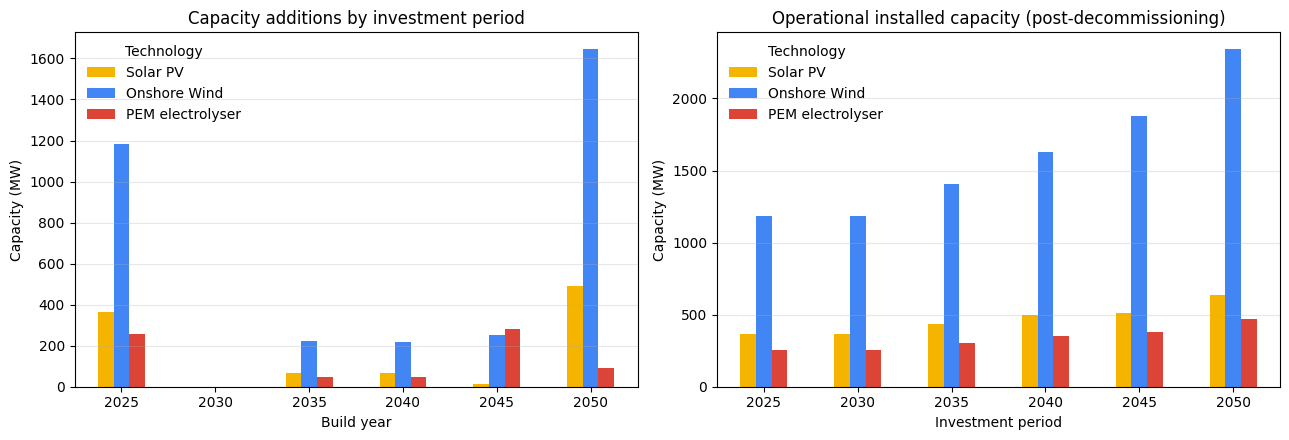

In [10]:
import matplotlib.pyplot as plt

# Added capacity per investment period (decision variable)
added = pd.DataFrame({
    "Solar PV":      [n.generators.at[f"solar_{by}", "p_nom_opt"] for by in INVESTMENT_PERIODS],
    "Onshore Wind":  [n.generators.at[f"wind_{by}",  "p_nom_opt"] for by in INVESTMENT_PERIODS],
    "PEM electrolyser": [n.links.at[f"pem_{by}",     "p_nom_opt"] for by in INVESTMENT_PERIODS],
}, index=INVESTMENT_PERIODS)
added.index.name = "Build year"

# Operational capacity per period (cumulative, accounting for lifetime)
lifetimes = {"Solar PV": 25, "Onshore Wind": 25, "PEM electrolyser": 20}
operational = pd.DataFrame(0.0, index=INVESTMENT_PERIODS, columns=added.columns)
for tech, lt in lifetimes.items():
    for by in INVESTMENT_PERIODS:
        for y in INVESTMENT_PERIODS:
            if by <= y < by + lt:
                operational.at[y, tech] += added.at[by, tech]

print("Capacity ADDED in each investment period (MW):")
print(added.round(1))
print("\nOperational capacity per period, after decommissioning (MW):")
print(operational.round(1))
print(f"\nTotal objective (NPV, €): {n.objective:,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = ["#F4B400", "#4285F4", "#DB4437"]   # solar yellow, wind blue, electrolyser red

added.plot(kind="bar", ax=axes[0], color=colors)
axes[0].set_title("Capacity additions by investment period")
axes[0].set_ylabel("Capacity (MW)")
axes[0].set_xlabel("Build year")
axes[0].legend(title="Technology", frameon=False)
axes[0].grid(axis="y", alpha=0.3)
axes[0].tick_params(axis="x", rotation=0)

operational.plot(kind="bar", ax=axes[1], color=colors)
axes[1].set_title("Operational installed capacity (post-decommissioning)")
axes[1].set_ylabel("Capacity (MW)")
axes[1].set_xlabel("Investment period")
axes[1].legend(title="Technology", frameon=False)
axes[1].grid(axis="y", alpha=0.3)
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [11]:
# Excel reader setup
EXCEL_PATH = DATA_DIR / "oil_majors_h2_data_collection.xlsx"
print(f"Reading from: {EXCEL_PATH}")
print(f"File exists:  {EXCEL_PATH.exists()}")

# List all sheets in the workbook
xl = pd.ExcelFile(EXCEL_PATH)
print(f"\nSheets found ({len(xl.sheet_names)}):")
for s in xl.sheet_names:
    print(f"  - {s}")

Reading from: C:\Users\m\Documents\Tese\Article4\data\oil_majors_h2_data_collection.xlsx
File exists:  True

Sheets found (12):
  - 00_README
  - 01_Company_Overview
  - 02_Refinery_Inventory
  - 03_Current_H2_Demand
  - 04_GreenH2_Projects
  - 05_Renewable_Portfolio
  - 06_PPAs
  - 07_Decarb_Targets
  - 08_Financial_Disclosures
  - 09_Cost_Params_MC
  - 10_Climate_Scenarios
  - 11_Sources


In [12]:
def read_sheet(sheet_name: str, header_row: int = 0) -> pd.DataFrame:
    """
    Read a sheet from the data workbook, defensively.
    Returns DataFrame even if all data cells are empty (lets us inspect structure).
    """
    df = pd.read_excel(EXCEL_PATH, sheet_name=sheet_name, header=header_row)
    # Drop fully empty rows (artifact of pre-allocated rows in the template)
    df = df.dropna(how="all").reset_index(drop=True)
    return df


def is_empty(value) -> bool:
    """True if value is NaN, None, empty string, or whitespace-only."""
    if pd.isna(value):
        return True
    if isinstance(value, str) and value.strip() == "":
        return True
    return False


def report_completeness(df: pd.DataFrame, sheet_name: str,
                        key_columns: list[str]) -> None:
    """Print a quick fill-rate report for the columns that matter for the model."""
    print(f"\n=== {sheet_name} ===")
    print(f"Rows (after dropping empty): {len(df)}")
    if len(df) == 0:
        print("  (sheet is empty)")
        return
    print("Fill rate of key columns:")
    for col in key_columns:
        if col not in df.columns:
            print(f"  {col:<35} NOT FOUND in columns")
            continue
        filled = df[col].apply(lambda v: not is_empty(v)).sum()
        pct = 100 * filled / len(df)
        bar = "█" * int(pct / 5) + "·" * (20 - int(pct / 5))
        print(f"  {col:<35} {filled:>3}/{len(df):<3}  {pct:>5.0f}%  {bar}")


print("Helper functions defined.")

Helper functions defined.


In [15]:
# Run a completeness audit on the sheets that feed the model directly.
# Some sheets have decorative header rows above the column names — specify header_row.

sheets_to_audit = {
    "01_Company_Overview": (0, [
        "Company",
        "Total CAPEX (€bn)",
        "Low-carbon CAPEX (€bn)",
        "EU refining capacity (kbpd)",
        "Announced green H₂ by 2030 (kt/y)",
        "Net-zero target year",
        "Source_ID",
    ]),
    "02_Refinery_Inventory": (0, [
        "Company", "Refinery", "Country",
        "Nameplate capacity (kbpd)",
        "Status (Operating / Idled / Converting / Closed)",
        "Source_ID",
    ]),
    "03_Current_H2_Demand": (0, [
        "Company", "Refinery",
        "Captive SMR H₂ (kt/y)",
        "Total H₂ demand (kt/y)",
        "Source_ID",
    ]),
    "04_GreenH2_Projects": (0, [
        "Company", "Project name",
        "Electrolyser capacity (MWel)",
        "CAPEX (€m)", "COD (year)",
        "Status (Announced / FEED / FID / UC / Operational / Cancelled)",
        "Source_ID",
    ]),
    "07_Decarb_Targets": (0, [
        "Company",
        "Scope 1 baseline (Mt CO₂e)",
        "Net-zero year (Scope 1+2)",
        "Internal carbon price (€/t CO₂)",
        "Source_ID",
    ]),
    "09_Cost_Params_MC": (3, [   # decorative title rows above headers → header on row 4
        "Technology / Parameter",
        "Min", "Mode", "Max", "Source_ID",
    ]),
    "10_Climate_Scenarios": (0, [
        "Scenario", "Variable", "Source_ID",
    ]),
    "11_Sources": (0, [
        "Source_ID", "Title", "URL / DOI",
    ]),
}

for sheet, (header_row, key_cols) in sheets_to_audit.items():
    df = read_sheet(sheet, header_row=header_row)
    report_completeness(df, sheet, key_cols)


=== 01_Company_Overview ===
Rows (after dropping empty): 5
Fill rate of key columns:
  Company                               5/5      100%  ████████████████████
  Total CAPEX (€bn)                     0/5        0%  ····················
  Low-carbon CAPEX (€bn)                0/5        0%  ····················
  EU refining capacity (kbpd)           0/5        0%  ····················
  Announced green H₂ by 2030 (kt/y)     0/5        0%  ····················
  Net-zero target year                  0/5        0%  ····················
  Source_ID                             0/5        0%  ····················

=== 02_Refinery_Inventory ===
Rows (after dropping empty): 23
Fill rate of key columns:
  Company                              23/23     100%  ████████████████████
  Refinery                             22/23      96%  ███████████████████·
  Country                              22/23      96%  ███████████████████·
  Nameplate capacity (kbpd)             0/23       0%  ··········

In [16]:
def load_cost_params(scenario_mode: str = "mode") -> pd.DataFrame:
    """
    Load technology cost parameters from sheet 09 for use in the PyPSA model.
    
    Parameters
    ----------
    scenario_mode : str
        Which point estimate to use: 'min', 'mode', 'max', or 'mean' (of min,mode,max).
        For Monte Carlo we'll sample from the triangular dist; for deterministic
        baseline runs, use 'mode'.
    
    Returns
    -------
    DataFrame indexed by parameter name, with one 'value' column.
    """
    df = read_sheet("09_Cost_Params_MC", header_row=3)   # headers are on row 4 (0-indexed 3)
    # Drop section-divider rows (those starting with "—")
    df = df[~df["Technology / Parameter"].astype(str).str.startswith("—")]
    df = df.dropna(subset=["Technology / Parameter"]).reset_index(drop=True)
    
    if scenario_mode == "mean":
        df["value"] = df[["Min", "Mode", "Max"]].mean(axis=1)
    else:
        df["value"] = df[scenario_mode.capitalize()]
    
    result = df.set_index("Technology / Parameter")[["Unit", "value", "Source_ID"]]
    return result


# Test it (will return mostly NaNs since the sheet is empty, but should not crash)
try:
    costs = load_cost_params(scenario_mode="mode")
    print(f"Loaded {len(costs)} cost parameters from sheet 09_Cost_Params_MC")
    print(f"\nFirst 5 rows:")
    print(costs.head())
    print(f"\nFilled parameters (non-NaN 'value'): {costs['value'].notna().sum()} / {len(costs)}")
except Exception as e:
    print(f"Loader failed with: {type(e).__name__}: {e}")
    print("→ Likely cause: column names in sheet 09 don't match expectations.")
    print("→ Run: pd.read_excel(EXCEL_PATH, '09_Cost_Params_MC', header=3).columns.tolist()")

Loaded 28 cost parameters from sheet 09_Cost_Params_MC

First 5 rows:
                                      Unit  value  Source_ID
Technology / Parameter                                      
PEM CAPEX                             €/kW    NaN        NaN
PEM OPEX (% CAPEX/y)                   %/y    NaN        NaN
PEM efficiency (LHV)                     %    NaN        NaN
PEM stack lifetime                       h    NaN        NaN
PEM stack replacement cost (% CAPEX)     %    NaN        NaN

Filled parameters (non-NaN 'value'): 0 / 28


In [17]:
def load_refineries(only_operating: bool = False) -> pd.DataFrame:
    """
    Load refinery inventory from sheet 02.
    
    Parameters
    ----------
    only_operating : bool
        If True, drop refineries whose Status doesn't contain 'Operating'.
        For early development this stays False so we see the full template.
    
    Returns
    -------
    DataFrame indexed by Refinery, with columns for the model:
        company, country, location, capacity_kbpd, status, source_id
    """
    df = read_sheet("02_Refinery_Inventory", header_row=0)
    
    # Standardise column names to snake_case for code-friendliness
    rename_map = {
        "Company": "company",
        "Refinery": "refinery",
        "Country": "country",
        "Location (city)": "location",
        "Ownership %": "ownership_pct",
        "Nameplate capacity (kbpd)": "capacity_kbpd",
        "Nelson complexity": "nelson",
        "Status (Operating / Idled / Converting / Closed)": "status",
        "Conversion plan": "conversion_plan",
        "Source_ID": "source_id",
    }
    df = df.rename(columns=rename_map)
    keep = [c for c in rename_map.values() if c in df.columns]
    df = df[keep].copy()
    
    # Drop the trailing instructional note row (it has text in column 1 only)
    df = df[df["company"].notna() & df["refinery"].notna()].reset_index(drop=True)
    
    if only_operating and "status" in df.columns:
        df = df[df["status"].astype(str).str.contains("Operating", na=False)].reset_index(drop=True)
    
    return df


# Test
refs = load_refineries()
print(f"Loaded {len(refs)} refineries")
print(f"\nBreakdown by company:")
print(refs["company"].value_counts())
print(f"\nFirst 5 rows:")
print(refs.head().to_string(index=False))

# Critical metric for the model
filled_capacity = refs["capacity_kbpd"].notna().sum() if "capacity_kbpd" in refs.columns else 0
print(f"\nRefineries with capacity_kbpd filled: {filled_capacity}/{len(refs)}")

Loaded 22 refineries

Breakdown by company:
company
TotalEnergies SE    7
Eni S.p.A.          5
Repsol S.A.         5
BP plc              3
Shell plc           2
Name: count, dtype: int64

First 5 rows:
         company                       refinery     country  location  ownership_pct  capacity_kbpd  nelson  status  conversion_plan  source_id
       Shell plc                         Pernis Netherlands Rotterdam            NaN            NaN     NaN     NaN              NaN        NaN
       Shell plc Rheinland (Wesseling + Godorf)     Germany   Cologne            NaN            NaN     NaN     NaN              NaN        NaN
TotalEnergies SE                         Donges      France    Donges            NaN            NaN     NaN     NaN              NaN        NaN
TotalEnergies SE                    Gonfreville      France  Le Havre            NaN            NaN     NaN     NaN              NaN        NaN
TotalEnergies SE                         Feyzin      France      Lyon        

In [18]:
def load_h2_projects(min_status: str = "Announced") -> pd.DataFrame:
    """
    Load green H2 project pipeline from sheet 04.

    Parameters
    ----------
    min_status : str
        Lowest project maturity to include. Order: Announced < FEED < FID < UC < Operational.
        For Article 4 modelling we typically include FID+ as 'committed';
        Announced/FEED as 'optional pipeline'.

    Returns
    -------
    DataFrame with one row per project, columns:
        company, project, country, site, capacity_mw, technology,
        h2_output_kt_y, capex_eur_m, cod_year, status, source_id
    """
    df = read_sheet("04_GreenH2_Projects", header_row=0)
    
    rename_map = {
        "Company": "company",
        "Project name": "project",
        "Country": "country",
        "Site / refinery linked": "site",
        "Partners": "partners",
        "Electrolyser capacity (MWel)": "capacity_mw",
        "Technology (PEM / AEL / SOEC)": "technology",
        "Expected H₂ output (kt/y)": "h2_output_kt_y",
        "CAPEX (€m)": "capex_eur_m",
        "Public funding (€m)": "public_funding_eur_m",
        "Funding scheme": "funding_scheme",
        "Year announced": "year_announced",
        "FID year": "fid_year",
        "COD (year)": "cod_year",
        "Status (Announced / FEED / FID / UC / Operational / Cancelled)": "status",
        "Offtake / end-use": "offtake",
        "Source_ID": "source_id",
    }
    df = df.rename(columns=rename_map)
    keep = [c for c in rename_map.values() if c in df.columns]
    df = df[keep].copy()
    
    # Drop fully empty pre-allocated rows
    df = df[df["project"].notna() | df["company"].notna()].reset_index(drop=True)
    
    # Filter by minimum status (only if status column has data)
    status_order = ["Announced", "FEED", "FID", "UC", "Operational"]
    if min_status in status_order and "status" in df.columns:
        valid = status_order[status_order.index(min_status):]
        df_with_status = df[df["status"].astype(str).isin(valid)]
        # Keep rows with NaN status too during development (don't hide template rows)
        df = pd.concat([df_with_status, df[df["status"].isna()]]).reset_index(drop=True)
    
    return df


# Test
projects = load_h2_projects(min_status="Announced")
print(f"Loaded {len(projects)} projects")
if len(projects) > 0:
    print(f"\nBy company:")
    print(projects["company"].value_counts())
    filled_capex = projects["capex_eur_m"].notna().sum()
    filled_cod = projects["cod_year"].notna().sum()
    print(f"\nWith CAPEX disclosed:   {filled_capex}/{len(projects)}")
    print(f"With COD disclosed:     {filled_cod}/{len(projects)}")

Loaded 1 projects

By company:
company
Recommended sources: IEA Hydrogen Projects Database (https://www.iea.org/data-and-statistics/data-product/hydrogen-projects-database), Hydrogen Europe Clean Hydrogen Monitor, company press releases. Cross-check CAPEX against Clean Hydrogen Partnership / IPCEI Hy2Tech & Hy2Use funding decisions.    1
Name: count, dtype: int64

With CAPEX disclosed:   0/1
With COD disclosed:     0/1


In [20]:
def load_climate_scenarios() -> pd.DataFrame:
    """
    Load STEPS/APS/NZE trajectories from sheet 10.
    """
    df = read_sheet("10_Climate_Scenarios", header_row=0)
    
    df = df.rename(columns={
        "Scenario": "scenario",
        "Variable": "variable",
        "Source_ID": "source_id",
        "Notes": "notes",
    })
    
    # Detect year columns. Keep ORIGINAL labels (string or int — whatever pandas read).
    year_cols_original = []
    year_cols_int = []
    for c in df.columns:
        try:
            y = int(c)
            if 2020 <= y <= 2060:
                year_cols_original.append(c)
                year_cols_int.append(y)
        except (ValueError, TypeError):
            continue
    
    if not year_cols_original:
        print("Warning: no year columns detected in sheet 10. Check header_row.")
        return pd.DataFrame()
    
    id_vars = [c for c in ["scenario", "variable", "source_id"] if c in df.columns]
    df_long = df.melt(
        id_vars=id_vars,
        value_vars=year_cols_original,   # use original labels, not converted ints
        var_name="year",
        value_name="value",
    )
    df_long["year"] = pd.to_numeric(df_long["year"], errors="coerce").astype("Int64")
    df_long = df_long.dropna(subset=["scenario", "variable"]).reset_index(drop=True)
    return df_long


def get_scenario_trajectory(scenario: str, variable_contains: str) -> pd.Series:
    """Return a single trajectory as Series indexed by year."""
    df = load_climate_scenarios()
    sel = df[(df["scenario"] == scenario)
             & (df["variable"].astype(str).str.contains(variable_contains, case=False, regex=False))]
    if len(sel) == 0:
        print(f"  No match for scenario='{scenario}', variable contains '{variable_contains}'")
        return pd.Series(dtype=float)
    return sel.set_index("year")["value"].sort_index()


# Test
scenarios_df = load_climate_scenarios()
print(f"Loaded {len(scenarios_df)} (scenario, variable, year) cells")
if len(scenarios_df) > 0:
    print(f"\nScenarios present: {sorted(scenarios_df['scenario'].unique())}")
    print(f"Variables present: {scenarios_df['variable'].nunique()}")
    filled = scenarios_df["value"].notna().sum()
    print(f"Cells with values filled: {filled}/{len(scenarios_df)} ({100*filled/len(scenarios_df):.0f}%)")
    
    print("\n--- Example: NZE carbon price trajectory ---")
    traj = get_scenario_trajectory("NZE", "Carbon price")
    print(traj)

Loaded 126 (scenario, variable, year) cells

Scenarios present: ['APS', 'NZE', 'STEPS']
Variables present: 7
Cells with values filled: 0/126 (0%)

--- Example: NZE carbon price trajectory ---
year
2025   NaN
2030   NaN
2035   NaN
2040   NaN
2045   NaN
2050   NaN
Name: value, dtype: float64


In [21]:
# Quick dashboard: how much real data is now reachable from the model?
print("=" * 60)
print("DATA AVAILABILITY DASHBOARD")
print("=" * 60)

costs = load_cost_params(scenario_mode="mode")
refs = load_refineries()
projects = load_h2_projects()
scenarios_df = load_climate_scenarios()

def fill_rate(s):
    if len(s) == 0:
        return "0/0   (empty)"
    n = s.notna().sum()
    return f"{n}/{len(s)} ({100*n/len(s):.0f}%)"

print(f"\nCost parameters (sheet 09):")
print(f"  rows in sheet:      {len(costs)}")
print(f"  with value filled:  {fill_rate(costs['value'])}")

print(f"\nRefineries (sheet 02):")
print(f"  rows in sheet:      {len(refs)}")
print(f"  with capacity_kbpd: {fill_rate(refs['capacity_kbpd']) if 'capacity_kbpd' in refs.columns else 'col missing'}")
print(f"  with status:        {fill_rate(refs['status']) if 'status' in refs.columns else 'col missing'}")

print(f"\nH2 projects (sheet 04):")
print(f"  rows in sheet:      {len(projects)}")
if len(projects) > 0:
    print(f"  with capacity_mw:   {fill_rate(projects['capacity_mw'])}")
    print(f"  with cod_year:      {fill_rate(projects['cod_year'])}")
    print(f"  with capex_eur_m:   {fill_rate(projects['capex_eur_m'])}")

print(f"\nClimate scenarios (sheet 10):")
print(f"  total cells:        {len(scenarios_df)}")
if len(scenarios_df) > 0:
    print(f"  with value filled:  {fill_rate(scenarios_df['value'])}")

print("\n" + "=" * 60)
print("Bridge Excel → model is in place. As you fill the workbook,")
print("re-run this cell to see progress. No code changes needed.")
print("=" * 60)

DATA AVAILABILITY DASHBOARD

Cost parameters (sheet 09):
  rows in sheet:      28
  with value filled:  0/28 (0%)

Refineries (sheet 02):
  rows in sheet:      22
  with capacity_kbpd: 0/22 (0%)
  with status:        0/22 (0%)

H2 projects (sheet 04):
  rows in sheet:      1
  with capacity_mw:   0/1 (0%)
  with cod_year:      0/1 (0%)
  with capex_eur_m:   0/1 (0%)

Climate scenarios (sheet 10):
  total cells:        126
  with value filled:  0/126 (0%)

Bridge Excel → model is in place. As you fill the workbook,
re-run this cell to see progress. No code changes needed.


In [22]:
def load_h2_projects(min_status: str = "Announced") -> pd.DataFrame:
    """Load green H2 project pipeline from sheet 04."""
    df = read_sheet("04_GreenH2_Projects", header_row=0)
    
    rename_map = {
        "Company": "company", "Project name": "project", "Country": "country",
        "Site / refinery linked": "site", "Partners": "partners",
        "Electrolyser capacity (MWel)": "capacity_mw",
        "Technology (PEM / AEL / SOEC)": "technology",
        "Expected H₂ output (kt/y)": "h2_output_kt_y",
        "CAPEX (€m)": "capex_eur_m", "Public funding (€m)": "public_funding_eur_m",
        "Funding scheme": "funding_scheme", "Year announced": "year_announced",
        "FID year": "fid_year", "COD (year)": "cod_year",
        "Status (Announced / FEED / FID / UC / Operational / Cancelled)": "status",
        "Offtake / end-use": "offtake", "Source_ID": "source_id",
    }
    df = df.rename(columns=rename_map)
    keep = [c for c in rename_map.values() if c in df.columns]
    df = df[keep].copy()
    
    # Real project rows must have BOTH a company name AND a project name.
    # This filters out the trailing instructional note ("Recommended sources: ...").
    df = df[df["company"].notna() & df["project"].notna()].reset_index(drop=True)
    
    # Real companies are one of FIRMS — defensive filter against text accidentally
    # caught in the company column.
    df = df[df["company"].isin(FIRMS + [f"{f} plc" for f in FIRMS] + 
                                ["Shell plc", "TotalEnergies SE", "BP plc",
                                 "Eni S.p.A.", "Repsol S.A."])].reset_index(drop=True)
    
    return df


projects = load_h2_projects()
print(f"Loaded {len(projects)} projects (after filtering)")

Loaded 0 projects (after filtering)


In [23]:
# Capture the current environment into requirements.txt
import subprocess, sys

result = subprocess.run(
    [sys.executable, "-m", "pip", "freeze"],
    capture_output=True, text=True, check=True,
)
all_packages = result.stdout

# Filter to just the packages we actually care about (avoid 200+ noise lines)
KEY_PACKAGES = [
    "pypsa", "linopy", "highspy",
    "numpy", "pandas", "scipy", "xarray",
    "matplotlib", "seaborn",
    "openpyxl",
    "tsam", "scikit-learn",
    "jupyterlab", "ipykernel",
]

requirements_path = PROJECT_ROOT / "requirements.txt"
with open(requirements_path, "w") as f:
    f.write("# Article 4 — frozen environment\n")
    f.write("# Generated automatically. To reproduce:\n")
    f.write("#   conda create -n tese-h2 python=3.11 -y\n")
    f.write("#   conda activate tese-h2\n")
    f.write("#   pip install -r requirements.txt\n\n")
    
    for line in all_packages.splitlines():
        pkg_name = line.split("==")[0].split(" ")[0].lower()
        if pkg_name in KEY_PACKAGES:
            f.write(line + "\n")

print(f"Written: {requirements_path}")
print()
print("Content:")
print(open(requirements_path).read())

Written: C:\Users\m\Documents\Tese\Article4\requirements.txt

Content:
# Article 4 — frozen environment
# Generated automatically. To reproduce:
#   conda create -n tese-h2 python=3.11 -y
#   conda activate tese-h2
#   pip install -r requirements.txt

highspy==1.14.0
ipykernel==7.2.0
jupyterlab==4.5.7
linopy==0.5.8
matplotlib==3.10.9
numpy==1.26.4
openpyxl==3.1.5
pandas==2.2.3
pypsa==0.35.1
scikit-learn==1.8.0
scipy==1.17.1
seaborn==0.13.2
tsam==3.4.0
xarray==2024.11.0



In [24]:
environment_yml = """\
# Article 4 — Conda environment specification
# Reproduce with:  conda env create -f environment.yml

name: tese-h2
channels:
  - conda-forge
  - defaults
dependencies:
  - python=3.11
  - pip
  - pip:
    - -r requirements.txt
"""

env_path = PROJECT_ROOT / "environment.yml"
with open(env_path, "w") as f:
    f.write(environment_yml)

print(f"Written: {env_path}")
print()
print(open(env_path).read())

Written: C:\Users\m\Documents\Tese\Article4\environment.yml

# Article 4 — Conda environment specification
# Reproduce with:  conda env create -f environment.yml

name: tese-h2
channels:
  - conda-forge
  - defaults
dependencies:
  - python=3.11
  - pip
  - pip:
    - -r requirements.txt



In [26]:
readme_lines = [
    "# Article 4 - Paris-aligned Green Hydrogen Pathways for European Oil Majors",
    "",
    "PhD thesis (Ernesto Relogio, Universidade de Aveiro).",
    "Multi-firm energy system optimisation framework with stochastic LCOH and",
    "real options analysis under climate budget constraints.",
    "",
    "## Folder structure",
    "",
    "    Article4/",
    "    |-- notebooks/              Jupyter notebooks, numbered by stage",
    "    |   `-- 01_smoke_test.ipynb",
    "    |-- data/                   Source data (Excel workbook + raw downloads)",
    "    |   `-- oil_majors_h2_data_collection.xlsx",
    "    |-- results/                Model outputs (NetCDF, parquet, figures)",
    "    |-- refs/                   Reference PDFs (annual reports, IEA, IRENA)",
    "    |-- requirements.txt        Frozen Python dependencies",
    "    |-- environment.yml         Conda environment specification",
    "    `-- README.md",
    "",
    "## Environment",
    "",
    "Python 3.11, PyPSA 0.35.1, HiGHS solver. To rebuild:",
    "",
    "    conda create -n tese-h2 python=3.11 -y",
    "    conda activate tese-h2",
    "    pip install -r requirements.txt",
    "    python -m ipykernel install --user --name tese-h2",
    "",
    "## Methodology in three layers",
    "",
    "L1: Deterministic capacity expansion (5 firms x 3 climate scenarios x 2 foresight modes = 30 runs). PyPSA + HiGHS.",
    "L2: Stochastic LCOH on fixed capacities (10,000 MC). NumPy / pandas.",
    "L3: Real options analysis (Longstaff-Schwartz). NumPy.",
    "",
    "## Investment horizon",
    "",
    "2025-2050 in 5-year steps. Discount rate 5%. Vintages with lifetime decommissioning.",
    "",
    "## Climate scenarios (from IEA WEO)",
    "",
    "- STEPS - Stated Policies",
    "- APS - Announced Pledges",
    "- NZE - Net Zero Emissions by 2050",
    "",
    "## Firms",
    "",
    "Shell plc, TotalEnergies SE, BP plc, Eni S.p.A., Repsol S.A.",
    "",
    "## Status",
    "",
    "- [x] Environment frozen",
    "- [x] PyPSA multi-period model running (1554 vars, optimal in <2s)",
    "- [x] Excel data template (12 sheets, defensive loaders)",
    "- [ ] Data collection in workbook (in progress)",
    "- [ ] Typical days via tsam",
    "- [ ] CO2 budget constraint per firm",
    "- [ ] Full 30-run pipeline",
    "- [ ] L2 Monte Carlo LCOH",
    "- [ ] L3 Longstaff-Schwartz real options",
    "- [ ] Manuscript draft",
    "",
    "## Reproducibility note",
    "",
    "Versions are pinned because PyPSA 1.0 (released early 2026) introduced a",
    "regression in multi_investment_periods. Last working stable version is 0.35.1.",
    "Do not upgrade PyPSA mid-project.",
]

readme_text = "\n".join(readme_lines)

readme_path = PROJECT_ROOT / "README.md"
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_text)

print(f"Written: {readme_path}")
print(f"Size: {readme_path.stat().st_size} bytes")

Written: C:\Users\m\Documents\Tese\Article4\README.md
Size: 2287 bytes


In [28]:
readme_lines = [
    "# Article 4 - Paris-aligned Green Hydrogen Pathways for European Oil Majors",
    "",
    "PhD thesis (Ernesto Relogio, Universidade de Aveiro).",
    "Multi-firm energy system optimisation framework with stochastic LCOH and",
    "real options analysis under climate budget constraints.",
    "",
    "## Folder structure",
    "",
    "    Article4/",
    "    |-- notebooks/              Jupyter notebooks",
    "    |-- data/                   Excel workbook + raw downloads",
    "    |-- results/                Model outputs",
    "    |-- refs/                   Reference PDFs",
    "    |-- requirements.txt        Frozen Python dependencies",
    "    |-- environment.yml         Conda environment specification",
    "    `-- README.md",
    "",
    "## Environment",
    "",
    "Python 3.11, PyPSA 0.35.1, HiGHS solver. To rebuild:",
    "",
    "    conda create -n tese-h2 python=3.11 -y",
    "    conda activate tese-h2",
    "    pip install -r requirements.txt",
    "",
    "## Methodology in three layers",
    "",
    "L1: Deterministic capacity expansion (5 firms by 3 climate scenarios by 2 foresight modes = 30 runs). PyPSA + HiGHS.",
    "L2: Stochastic LCOH on fixed capacities (10000 MC). NumPy / pandas.",
    "L3: Real options analysis (Longstaff-Schwartz). NumPy.",
    "",
    "## Investment horizon",
    "",
    "2025-2050 in 5-year steps. Discount rate 5 percent. Vintages with lifetime decommissioning.",
    "",
    "## Climate scenarios (from IEA WEO)",
    "",
    "- STEPS - Stated Policies",
    "- APS - Announced Pledges",
    "- NZE - Net Zero Emissions by 2050",
    "",
    "## Firms",
    "",
    "Shell plc, TotalEnergies SE, BP plc, Eni S.p.A., Repsol S.A.",
    "",
    "## Status",
    "",
    "- [x] Environment frozen",
    "- [x] PyPSA multi-period model running (1554 vars, optimal in under 2s)",
    "- [x] Excel data template (12 sheets, defensive loaders)",
    "- [ ] Data collection in workbook (in progress)",
    "- [ ] Typical days via tsam",
    "- [ ] CO2 budget constraint per firm",
    "- [ ] Full 30-run pipeline",
    "- [ ] L2 Monte Carlo LCOH",
    "- [ ] L3 Longstaff-Schwartz real options",
    "- [ ] Manuscript draft",
    "",
    "## Reproducibility note",
    "",
    "Versions are pinned because PyPSA 1.0 (released early 2026) introduced a",
    "regression in multi_investment_periods. Last working stable version is 0.35.1.",
    "Do not upgrade PyPSA mid-project.",
]

readme_text = "\n".join(readme_lines)

readme_path = PROJECT_ROOT / "README.md"
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_text)

print(f"Written: {readme_path}")
print(f"Size: {readme_path.stat().st_size} bytes")

Written: C:\Users\m\Documents\Tese\Article4\README.md
Size: 2075 bytes


In [39]:
print(f"PROJECT_ROOT: {PROJECT_ROOT}\n")
for item in sorted(PROJECT_ROOT.iterdir()):
    if item.is_dir():
        n = sum(1 for _ in item.iterdir())
        print(f"  [DIR]  {item.name}/  ({n} files)")
    else:
        size_kb = item.stat().st_size / 1024
        print(f"  [FILE] {item.name}  ({size_kb:.1f} KB)")

PROJECT_ROOT: C:\Users\m\Documents\Tese\Article4

  [DIR]  .ipynb_checkpoints/  (0 files)
  [DIR]  data/  (1 files)
  [FILE] environment.yml  (0.2 KB)
  [DIR]  notebooks/  (2 files)
  [FILE] README.md  (2.0 KB)
  [DIR]  refs/  (0 files)
  [FILE] requirements.txt  (0.4 KB)
  [DIR]  results/  (0 files)


In [40]:
def build_network(co2_budget_tco2: float = None) -> pypsa.Network:
    """
    Build the multi-period network from scratch.
    
    Parameters
    ----------
    co2_budget_tco2 : float or None
        Cumulative CO2 cap in tCO2 over 2025-2050.
        If None, no constraint is added (baseline unconstrained run).
    
    Returns
    -------
    Fresh pypsa.Network ready to .optimize().
    """
    net = pypsa.Network()
    net.set_snapshots(snapshots)
    net.set_investment_periods(INVESTMENT_PERIODS)
    
    T0 = INVESTMENT_PERIODS[0]
    net.investment_period_weightings["years"] = YEARS_PER_PERIOD
    net.investment_period_weightings["objective"] = [
        (1 + DISCOUNT_RATE) ** -(y - T0) for y in INVESTMENT_PERIODS
    ]
    sw_value = YEARS_PER_PERIOD * 8760 / N_HOURS_PER_PERIOD
    net.snapshot_weightings["objective"]  = sw_value
    net.snapshot_weightings["generators"] = sw_value
    net.snapshot_weightings["stores"]     = sw_value
    
    # Profiles
    rng = np.random.default_rng(SEED)
    hd  = np.arange(N_HOURS_PER_PERIOD) % 24
    solar_24h = np.clip(np.sin((hd - 6) / 12 * np.pi) * 0.7 + rng.normal(0, 0.05, N_HOURS_PER_PERIOD), 0, 1)
    solar_24h[(hd < 6) | (hd > 19)] = 0
    wind_24h  = np.clip(rng.beta(2, 4, N_HOURS_PER_PERIOD) * 1.1, 0, 1)
    solar_full = pd.Series(np.tile(solar_24h, len(INVESTMENT_PERIODS)), index=net.snapshots)
    wind_full  = pd.Series(np.tile(wind_24h,  len(INVESTMENT_PERIODS)), index=net.snapshots)
    h2_demand_per_period = {2025: 5, 2030: 5, 2035: 6, 2040: 7, 2045: 8, 2050: 10}
    h2_demand_full = pd.Series(
        [h2_demand_per_period[y] * 33.33 for y, _ in net.snapshots],
        index=net.snapshots,
    )
    
    # Carriers with CO2 factors
    net.add("Carrier", "AC",     co2_emissions=0)
    net.add("Carrier", "H2",     co2_emissions=0)
    net.add("Carrier", "solar",  co2_emissions=0)
    net.add("Carrier", "onwind", co2_emissions=0)
    net.add("Carrier", "grid",   co2_emissions=0.25)   # tCO2/MWh_el
    net.add("Carrier", "smr",    co2_emissions=0.30)   # tCO2/MWh_H2
    net.add("Carrier", "pem",    co2_emissions=0)
    
    # Buses and demand
    net.add("Bus", "power", carrier="AC")
    net.add("Bus", "h2",    carrier="H2")
    net.add("Load", "refinery_h2", bus="h2", p_set=h2_demand_full)
    
    # Existing supply (legacy)
    net.add("Generator", "grid_import", bus="power", carrier="grid",
            p_nom=1e6, marginal_cost=80.0)
    net.add("Generator", "smr", bus="h2", carrier="smr",
            p_nom=1e6, marginal_cost=40.0)
    
    # Vintages
    for by in INVESTMENT_PERIODS:
        row = CAPEX_TRAJ.loc[by]
        net.add("Generator", f"solar_{by}",
                bus="power", carrier="solar",
                p_nom_extendable=True, p_max_pu=solar_full,
                capital_cost=annuity_capex(row["solar_capex"] * 1000, row["wacc"], 25),
                build_year=by, lifetime=25)
        net.add("Generator", f"wind_{by}",
                bus="power", carrier="onwind",
                p_nom_extendable=True, p_max_pu=wind_full,
                capital_cost=annuity_capex(row["wind_capex"] * 1000, row["wacc"], 25),
                build_year=by, lifetime=25)
        net.add("Link", f"pem_{by}",
                bus0="power", bus1="h2", carrier="pem",
                p_nom_extendable=True, efficiency=row["pem_eff"], p_min_pu=0.10,
                capital_cost=annuity_capex(row["pem_capex"] * 1000, row["wacc"], 20),
                build_year=by, lifetime=20)
    
    # CO2 constraint — only if budget specified
    if co2_budget_tco2 is not None:
        net.add("GlobalConstraint", "co2_budget",
                sense="<=", constant=co2_budget_tco2,
                type="primary_energy", carrier_attribute="co2_emissions")
    
    return net


def weighted_energy_by_source(net):
    sw = net.snapshot_weightings["generators"]
    smr_mwh = (net.generators_t.p["smr"] * sw).groupby(level=0).sum()
    pem_links = [c for c in net.links.index if c.startswith("pem_")]
    pem_mwh = (net.links_t.p1[pem_links].abs().sum(axis=1) * sw).groupby(level=0).sum()
    demand_mwh = (net.loads_t.p["refinery_h2"] * sw).groupby(level=0).sum()
    return pd.DataFrame({
        "SMR (grey H2) [kt]":   (smr_mwh / 33.33 / 1000).round(1),
        "PEM (green H2) [kt]":  (pem_mwh / 33.33 / 1000).round(1),
        "Total demand [kt]":    (demand_mwh / 33.33 / 1000).round(1),
    })


def co2_emissions_by_period(net):
    sw = net.snapshot_weightings["generators"]
    smr_co2 = (net.generators_t.p["smr"] * sw * 0.30).groupby(level=0).sum()
    grid_co2 = (net.generators_t.p["grid_import"] * sw * 0.25).groupby(level=0).sum()
    return pd.DataFrame({
        "SMR CO2 [Mt]":   (smr_co2 / 1e6).round(3),
        "Grid CO2 [Mt]":  (grid_co2 / 1e6).round(3),
        "Total CO2 [Mt]": ((smr_co2 + grid_co2) / 1e6).round(3),
    })


print("build_network() + post-processing functions defined.")

build_network() + post-processing functions defined.


In [42]:
print("=" * 60)
print("UNCONSTRAINED BASELINE (no CO2 budget)")
print("=" * 60)

n_unc = build_network(co2_budget_tco2=None)
status = n_unc.optimize(solver_name="highs", multi_investment_periods=True)
print(f"\nSolver: {status}")
print(f"Active global constraints: {list(n_unc.global_constraints.index)}")

mix_unc = weighted_energy_by_source(n_unc)
co2_unc = co2_emissions_by_period(n_unc)

print("\nH2 supply mix (kt per period):")
print(mix_unc)
print("\nCO2 emissions (MtCO2 per period):")
print(co2_unc)

co2_total_unc = co2_unc["Total CO2 [Mt]"].sum()
print(f"\nTotal cumulative CO2: {co2_total_unc:.2f} MtCO2")
print(f"Total NPV:            {n_unc.objective/1e6:,.0f} M€")

UNCONSTRAINED BASELINE (no CO2 budget)


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.15s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1698 primals, 3666 duals
Objective: 7.41e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.



Solver: ('ok', 'optimal')
Active global constraints: []

H2 supply mix (kt per period):
        SMR (grey H2) [kt]  PEM (green H2) [kt]  Total demand [kt]
period                                                            
2025                  50.3                168.7              219.0
2030                  50.3                168.7              219.0
2035                  39.8                223.0              262.8
2040                  36.7                269.9              306.6
2045                  39.4                311.0              350.4
2050                  45.8                392.2              438.0

CO2 emissions (MtCO2 per period):
        SMR CO2 [Mt]  Grid CO2 [Mt]  Total CO2 [Mt]
period                                             
2025           0.503            0.0           0.503
2030           0.503            0.0           0.503
2035           0.398            0.0           0.398
2040           0.367            0.0           0.367
2045           0.393        

In [38]:
print("Active global constraints in network:")
print(n.global_constraints)

Active global constraints in network:
                            type  investment_period carrier_attribute sense  \
GlobalConstraint                                                              
co2_budget        primary_energy                NaN     co2_emissions    <=   

                  constant          mu  
GlobalConstraint                        
co2_budget           750.0 -589.586564  


In [43]:
print("=" * 60)
print("CONSTRAINED RUN (CO2 budget = 50% of unconstrained)")
print("=" * 60)

budget_tco2 = 0.5 * co2_total_unc * 1e6   # Mt → tCO2
print(f"Setting budget: {budget_tco2/1e6:.2f} MtCO2")

n_con = build_network(co2_budget_tco2=budget_tco2)
status = n_con.optimize(solver_name="highs", multi_investment_periods=True)
print(f"\nSolver: {status}")
print(f"Active global constraints: {list(n_con.global_constraints.index)}")

mix_con = weighted_energy_by_source(n_con)
co2_con = co2_emissions_by_period(n_con)

print("\nH2 supply mix (kt per period):")
print(mix_con)
print("\nCO2 emissions (MtCO2 per period):")
print(co2_con)

co2_total_con = co2_con["Total CO2 [Mt]"].sum()
print(f"\nTotal cumulative CO2: {co2_total_con:.2f} MtCO2 (budget was {budget_tco2/1e6:.2f})")
print(f"Total NPV:            {n_con.objective/1e6:,.0f} M€")
print(f"Cost premium vs baseline: {100*(n_con.objective/n_unc.objective - 1):+.1f}%")

# Shadow price
if "co2_budget" in n_con.global_constraints.index:
    shadow = n_con.global_constraints.at["co2_budget", "mu"]
    print(f"Shadow price of CO2 constraint: {-shadow:.1f} €/tCO2")

CONSTRAINED RUN (CO2 budget = 50% of unconstrained)
Setting budget: 1.31 MtCO2


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.14s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1698 primals, 3667 duals
Objective: 9.38e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.



Solver: ('ok', 'optimal')
Active global constraints: ['co2_budget']

H2 supply mix (kt per period):
        SMR (grey H2) [kt]  PEM (green H2) [kt]  Total demand [kt]
period                                                            
2025                   7.1                211.9              219.0
2030                   7.1                211.9              219.0
2035                   4.1                258.7              262.8
2040                   2.9                303.7              306.6
2045                   3.4                347.0              350.4
2050                   1.6                436.4              438.0

CO2 emissions (MtCO2 per period):
        SMR CO2 [Mt]  Grid CO2 [Mt]  Total CO2 [Mt]
period                                             
2025           0.071            0.0           0.071
2030           0.071            0.0           0.071
2035           0.041            0.0           0.041
2040           0.029            0.0           0.029
2045           0

In [44]:
import time

# Sweep CO2 budgets as fraction of unconstrained baseline
BUDGET_FRACTIONS = [1.00, 0.90, 0.75, 0.50, 0.25, 0.10, 0.05, 0.00]

# Need baseline first if not in memory
if "co2_total_unc" not in dir():
    print("Running unconstrained baseline first...")
    n_unc = build_network(co2_budget_tco2=None)
    n_unc.optimize(solver_name="highs", multi_investment_periods=True)
    co2_total_unc = co2_emissions_by_period(n_unc)["Total CO2 [Mt]"].sum()
    obj_unc = n_unc.objective
else:
    obj_unc = n_unc.objective

print(f"Baseline: {co2_total_unc:.3f} MtCO2, NPV {obj_unc/1e6:,.0f} M€\n")
print(f"Sweeping {len(BUDGET_FRACTIONS)} budgets...\n")

records = []
t_total = time.time()
for i, frac in enumerate(BUDGET_FRACTIONS):
    if frac >= 1.0:
        budget_tco2 = None
        budget_label = "Unconstrained"
    else:
        budget_tco2 = frac * co2_total_unc * 1e6   # Mt → tCO2
        budget_label = f"{int(frac*100)}% of baseline"
    
    t0 = time.time()
    net = build_network(co2_budget_tco2=budget_tco2)
    status = net.optimize(solver_name="highs", multi_investment_periods=True)
    elapsed = time.time() - t0
    
    if status[0] != "ok":
        print(f"  [{i+1}/{len(BUDGET_FRACTIONS)}] {budget_label:18s}  INFEASIBLE  ({elapsed:.1f}s)")
        records.append({
            "fraction": frac, "label": budget_label,
            "budget_MtCO2": budget_tco2/1e6 if budget_tco2 else None,
            "feasible": False, "elapsed_s": elapsed,
        })
        continue
    
    co2_realised = co2_emissions_by_period(net)["Total CO2 [Mt]"].sum()
    npv = net.objective
    
    shadow = None
    if "co2_budget" in net.global_constraints.index:
        shadow = -float(net.global_constraints.at["co2_budget", "mu"])
    
    records.append({
        "fraction": frac, "label": budget_label,
        "budget_MtCO2": budget_tco2/1e6 if budget_tco2 else None,
        "co2_realised_MtCO2": co2_realised,
        "abated_MtCO2": co2_total_unc - co2_realised,
        "npv_eur": npv,
        "extra_cost_eur": npv - obj_unc,
        "shadow_price_eur_tco2": shadow,
        "feasible": True,
        "elapsed_s": elapsed,
    })
    
    print(f"  [{i+1}/{len(BUDGET_FRACTIONS)}] {budget_label:18s}  "
          f"CO2={co2_realised:6.3f} Mt   NPV={npv/1e6:7,.0f} M€   "
          f"shadow={shadow:6.1f} €/tCO2   ({elapsed:.1f}s)" if shadow is not None
          else f"  [{i+1}/{len(BUDGET_FRACTIONS)}] {budget_label:18s}  "
               f"CO2={co2_realised:6.3f} Mt   NPV={npv/1e6:7,.0f} M€   "
               f"shadow=  N/A          ({elapsed:.1f}s)")

results = pd.DataFrame(records)
print(f"\nTotal sweep time: {time.time()-t_total:.1f}s")
print(f"\nResults table:")
print(results.to_string(index=False))

Baseline: 2.622 MtCO2, NPV 741 M€

Sweeping 8 budgets...



INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.13s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1698 primals, 3666 duals
Objective: 7.41e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.


  [1/8] Unconstrained       CO2= 2.622 Mt   NPV=    741 M€   shadow=  N/A          (3.8s)


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.14s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1698 primals, 3667 duals
Objective: 8.59e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.


  [2/8] 90% of baseline     CO2= 0.472 Mt   NPV=    859 M€   shadow=  53.0 €/tCO2   (2.4s)


...

  [6/8] 10% of baseline     CO2= 0.052 Mt   NPV=  1,121 M€   shadow= 318.7 €/tCO2   (2.4s)


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.13s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1698 primals, 3667 duals
Objective: 1.18e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.


  [7/8] 5% of baseline      CO2= 0.026 Mt   NPV=  1,177 M€   shadow= 489.8 €/tCO2   (2.3s)


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.14s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1698 primals, 3667 duals
Objective: 1.25e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.


  [8/8] 0% of baseline      CO2= 0.000 Mt   NPV=  1,251 M€   shadow= 611.5 €/tCO2   (2.3s)

Total sweep time: 20.3s

Results table:
 fraction           label  budget_MtCO2  co2_realised_MtCO2  abated_MtCO2      npv_eur  extra_cost_eur  shadow_price_eur_tco2  feasible  elapsed_s
     1.00   Unconstrained           NaN               2.622         0.000 7.411820e+08    0.000000e+00                    NaN      True   3.766577
     0.90 90% of baseline        2.3598               0.472         2.150 8.587539e+08    1.175719e+08              53.008462      True   2.423010
     0.75 75% of baseline        1.9665               0.393         2.229 8.806325e+08    1.394505e+08              70.375542      True   2.349658
     0.50 50% of baseline        1.3110               0.262         2.360 9.377707e+08    1.965887e+08             113.750890      True   2.370971
     0.25 25% of baseline        0.6555               0.130         2.492 1.028535e+09    2.873527e+08             192.709433      Tr

In [45]:
# Compute numerical marginal abatement cost: ΔNPV / ΔCO2 between consecutive runs
feasible = results[results["feasible"]].sort_values("co2_realised_MtCO2", ascending=False).reset_index(drop=True)

# Marginal cost between adjacent points
feasible["delta_co2_tco2"]  = -feasible["co2_realised_MtCO2"].diff() * 1e6   # tCO2 abated step
feasible["delta_npv_eur"]   =  feasible["npv_eur"].diff()                     # extra cost step
feasible["macc_numerical"]  =  feasible["delta_npv_eur"] / feasible["delta_co2_tco2"]

# Cumulative
feasible["cum_abated_tco2"] = (co2_total_unc * 1e6) - feasible["co2_realised_MtCO2"] * 1e6

print("Marginal Abatement Cost — numerical vs shadow price:\n")
cols = ["label", "co2_realised_MtCO2", "abated_MtCO2",
        "extra_cost_eur", "shadow_price_eur_tco2", "macc_numerical"]
print(feasible[cols].to_string(index=False))

Marginal Abatement Cost — numerical vs shadow price:

          label  co2_realised_MtCO2  abated_MtCO2  extra_cost_eur  shadow_price_eur_tco2  macc_numerical
  Unconstrained               2.622         0.000    0.000000e+00                    NaN             NaN
90% of baseline               0.472         2.150    1.175719e+08              53.008462       54.684615
75% of baseline               0.393         2.229    1.394505e+08              70.375542      276.944415
50% of baseline               0.262         2.360    1.965887e+08             113.750890      436.168915
25% of baseline               0.130         2.492    2.873527e+08             192.709433      687.606272
10% of baseline               0.052         2.570    3.797573e+08             318.741404     1184.674985
 5% of baseline               0.026         2.596    4.357969e+08             489.773837     2155.369717
 0% of baseline               0.000         2.622    5.095730e+08             611.464428     2837.541630


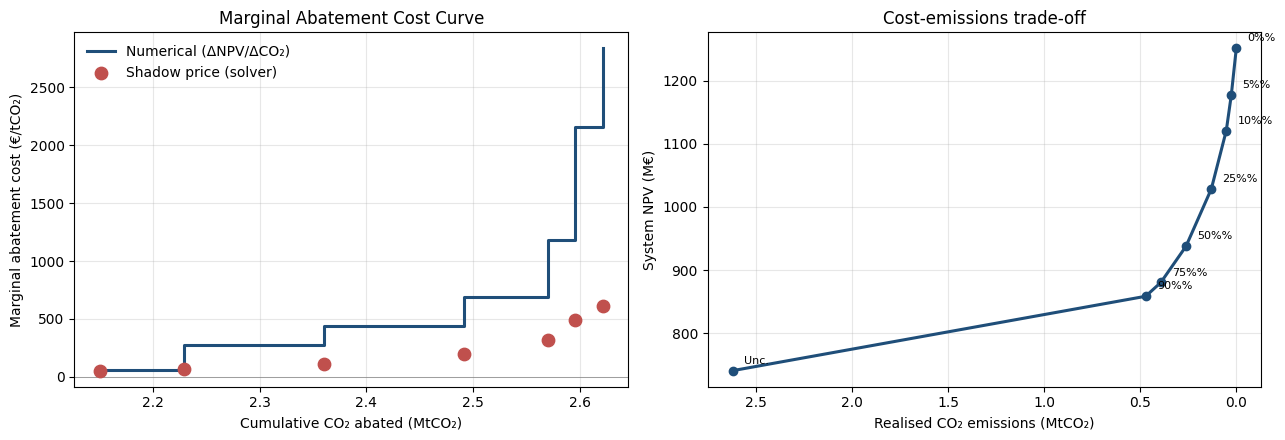

In [46]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: MACC curve (cumulative)
ax = axes[0]
plot_df = feasible.dropna(subset=["macc_numerical"]).copy()
ax.step(plot_df["cum_abated_tco2"]/1e6, plot_df["macc_numerical"],
        where="post", linewidth=2.2, color="#1f4e79", label="Numerical (ΔNPV/ΔCO₂)")

# Shadow prices as points
sp_df = feasible[feasible["shadow_price_eur_tco2"].notna()].copy()
sp_df["cum_abated_MtCO2"] = sp_df["cum_abated_tco2"] / 1e6
ax.scatter(sp_df["cum_abated_MtCO2"], sp_df["shadow_price_eur_tco2"],
           s=80, color="#c0504d", zorder=5, label="Shadow price (solver)")

ax.set_xlabel("Cumulative CO₂ abated (MtCO₂)")
ax.set_ylabel("Marginal abatement cost (€/tCO₂)")
ax.set_title("Marginal Abatement Cost Curve")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
ax.axhline(0, color="grey", linewidth=0.5)

# Right: NPV vs CO2 constraint level (cost-emissions trade-off)
ax = axes[1]
ax.plot(feasible["co2_realised_MtCO2"], feasible["npv_eur"]/1e6,
        marker="o", linewidth=2.2, color="#1f4e79")
for _, row in feasible.iterrows():
    ax.annotate(row["label"].replace(" of baseline", "%").replace("Unconstrained", "Unc."),
                (row["co2_realised_MtCO2"], row["npv_eur"]/1e6),
                textcoords="offset points", xytext=(8, 5), fontsize=8)
ax.set_xlabel("Realised CO₂ emissions (MtCO₂)")
ax.set_ylabel("System NPV (M€)")
ax.set_title("Cost-emissions trade-off")
ax.grid(alpha=0.3)
ax.invert_xaxis()   # increasing decarbonisation goes left→right

plt.tight_layout()
plt.show()

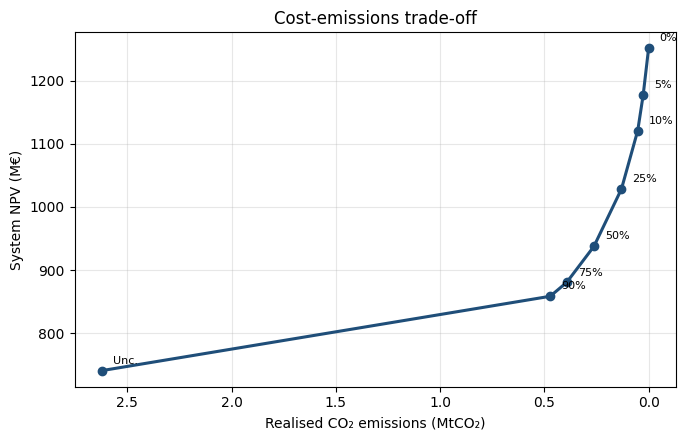

In [47]:
# Quick re-plot with cleaner labels
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(feasible["co2_realised_MtCO2"], feasible["npv_eur"]/1e6,
        marker="o", linewidth=2.2, color="#1f4e79")
for _, row in feasible.iterrows():
    label = row["label"].replace(" of baseline", "").replace("Unconstrained", "Unc.")
    ax.annotate(label, (row["co2_realised_MtCO2"], row["npv_eur"]/1e6),
                textcoords="offset points", xytext=(8, 5), fontsize=8)
ax.set_xlabel("Realised CO₂ emissions (MtCO₂)")
ax.set_ylabel("System NPV (M€)")
ax.set_title("Cost-emissions trade-off")
ax.grid(alpha=0.3)
ax.invert_xaxis()
plt.tight_layout()
plt.show()

In [48]:
readme_lines = [
    "# Article 4 - Paris-aligned Green Hydrogen Pathways for European Oil Majors",
    "",
    "PhD thesis (Ernesto Relogio, Universidade de Aveiro).",
    "Multi-firm energy system optimisation framework with stochastic LCOH and",
    "real options analysis under climate budget constraints.",
    "",
    "## Folder structure",
    "",
    "    Article4/",
    "    |-- notebooks/              Jupyter notebooks",
    "    |-- data/                   Excel workbook + raw downloads",
    "    |-- results/                Model outputs",
    "    |-- refs/                   Reference PDFs",
    "    |-- requirements.txt        Frozen Python dependencies",
    "    |-- environment.yml         Conda environment specification",
    "    `-- README.md",
    "",
    "## Environment",
    "",
    "Python 3.11, PyPSA 0.35.1, HiGHS solver. To rebuild:",
    "",
    "    conda create -n tese-h2 python=3.11 -y",
    "    conda activate tese-h2",
    "    pip install -r requirements.txt",
    "",
    "## Methodology in three layers",
    "",
    "L1: Deterministic capacity expansion (5 firms by 3 climate scenarios by 2 foresight modes = 30 runs). PyPSA + HiGHS.",
    "L2: Stochastic LCOH on fixed capacities (10000 MC). NumPy / pandas.",
    "L3: Real options analysis (Longstaff-Schwartz). NumPy.",
    "",
    "## Investment horizon",
    "",
    "2025-2050 in 5-year steps. Discount rate 5 percent. Vintages with lifetime decommissioning.",
    "",
    "## Climate scenarios (from IEA WEO)",
    "",
    "- STEPS - Stated Policies",
    "- APS - Announced Pledges",
    "- NZE - Net Zero Emissions by 2050",
    "",
    "## Firms",
    "",
    "Shell plc, TotalEnergies SE, BP plc, Eni S.p.A., Repsol S.A.",
    "",
    "## Status",
    "",
    "- [x] Environment frozen (PyPSA 0.35.1, pandas 2.2.3, numpy 1.26.4)",
    "- [x] PyPSA multi-period model running (1554 vars, optimal in under 2s)",
    "- [x] Excel data template (12 sheets, defensive loaders)",
    "- [x] CO2 budget constraint per firm (GlobalConstraint, primary_energy)",
    "- [x] MACC pipeline (budget sweep + shadow prices + cost-emissions trade-off)",
    "- [ ] Data collection in workbook (in progress)",
    "- [ ] Typical days via tsam",
    "- [ ] Couple load_cost_params to PyPSA (replace placeholder CAPEX_TRAJ)",
    "- [ ] Full 30-run pipeline (5 firms x 3 scenarios x 2 foresight modes)",
    "- [ ] L2 Monte Carlo LCOH",
    "- [ ] L3 Longstaff-Schwartz real options",
    "- [ ] Manuscript draft",
    "",
    "## Key results so far (synthetic data, placeholder costs)",
    "",
    "- Unconstrained baseline: 2.62 MtCO2 cumulative 2025-2050, NPV 741 M Eur",
    "- 50 percent CO2 budget: NPV +26.5 percent, shadow price 114 Eur/tCO2",
    "- MACC knee at ~95 percent decarbonisation, last 5 percent costs above 2000 Eur/tCO2",
    "",
    "## Reproducibility note",
    "",
    "Versions are pinned because PyPSA 1.0 (released early 2026) introduced a",
    "regression in multi_investment_periods. Last working stable version is 0.35.1.",
    "Do not upgrade PyPSA mid-project.",
]

readme_text = "\n".join(readme_lines)
readme_path = PROJECT_ROOT / "README.md"
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_text)

print(f"Updated: {readme_path}  ({readme_path.stat().st_size} bytes)")

Updated: C:\Users\m\Documents\Tese\Article4\README.md  (2643 bytes)
